<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
This task provides a comprehensive deep dive into Decision Trees as outlined in Chapter 5. We will begin by exploring the mathematical foundations of Gini Impurity and comparing it with Information Gain, followed by a comparative analysis of the ID3 and CART algorithms. We will then transition to Regression Trees, focusing on MSE minimization for continuous targets. The task further covers strategies to combat overfitting through pruning techniques and hyperparameter tuning. Finally, we will apply these concepts by building, visualizing, and evaluating a Decision Tree model on the Titanic dataset, concluding with a summary of the strengths and weaknesses of this model class.

## Gini Impurity Deep Dive

### Subtask:
Explain Gini Impurity theory and perform numerical calculations.


### Gini Impurity: Theory and Intuition

**Gini Impurity** is a measurement used in the CART (Classification and Regression Trees) algorithm to determine how 'pure' a node is. A node is considered 'pure' (Gini = 0) if all instances in that node belong to a single class.

#### The Formula
For a dataset with $J$ classes, the Gini Impurity $G$ for a node is calculated as:
$$G = 1 - \sum_{i=1}^{J} p_i^2$$
where $p_i$ is the probability/fraction of items labeled with class $i$ in the node.

#### Why Gini?
* **Efficiency**: Unlike Information Gain (which uses Entropy/Logarithms), Gini calculation only requires basic arithmetic (squaring and subtraction), making it computationally faster.
* **Range**: The value ranges from 0 (purest) to 0.5 (maximum impurity for a binary classification task).

#### Gini vs. Entropy
While both measure impurity, Gini tends to isolate the most frequent class in its own branch, whereas Entropy tends to produce slightly more balanced trees. In practice, they often lead to similar results.

**Reasoning**:
I will calculate the Gini Impurity for a hypothetical 'Wind' attribute to provide a concrete numerical example. I'll define a function for Gini and apply it to a scenario with two classes (e.g., Play Tennis: Yes/No) split by Wind (Weak/Strong).



In [6]:
def calculate_gini(counts):
    total = sum(counts)
    if total == 0:
        return 0
    p_squared_sum = sum([(count / total)**2 for count in counts])
    return 1 - p_squared_sum

# Example: Play Tennis dataset
# Parent: [9 Yes, 5 No]
parent_gini = calculate_gini([9, 5])

# Split on 'Wind'
# Weak: [6 Yes, 2 No]
# Strong: [3 Yes, 3 No]
weak_gini = calculate_gini([6, 2])
strong_gini = calculate_gini([3, 3])

# Weighted Gini for the split
weighted_gini = (8/14) * weak_gini + (6/14) * strong_gini
gini_gain = parent_gini - weighted_gini

print(f"Parent Gini Impurity: {parent_gini:.4f}")
print(f"Gini (Wind=Weak): {weak_gini:.4f}")
print(f"Gini (Wind=Strong): {strong_gini:.4f}")
print(f"Weighted Gini for 'Wind' split: {weighted_gini:.4f}")
print(f"Gini Gain (Impurity Reduction): {gini_gain:.4f}")

Parent Gini Impurity: 0.4592
Gini (Wind=Weak): 0.3750
Gini (Wind=Strong): 0.5000
Weighted Gini for 'Wind' split: 0.4286
Gini Gain (Impurity Reduction): 0.0306


## ID3 vs. CART Algorithms

### Subtask:
Analyze and compare the ID3 and CART algorithms.


### ID3 vs. CART: A Comparative Analysis

While both ID3 and CART are foundational Decision Tree algorithms, they differ significantly in their implementation and capabilities.

#### 1. Splitting Criteria
*   **ID3 (Iterative Dichotomiser 3):** Uses **Information Gain** (based on Entropy) to select the best attribute. However, Information Gain tends to favor attributes with many levels (e.g., ID numbers).
*   **CART (Classification and Regression Trees):** Uses **Gini Impurity** as its default criterion. It is computationally more efficient than ID3 because it avoids logarithmic calculations.

#### 2. Tree Structure
*   **ID3:** Creates **multi-way trees**. Each node can have as many branches as there are unique values for the selected categorical attribute.
*   **CART:** Creates **binary trees**. Each internal node has exactly two outgoing edges (e.g., Yes/No, <= value / > value). This typically results in deeper trees compared to ID3.

#### 3. Handling Variable Types
*   **ID3:** Originally designed for **categorical data** only. It does not natively handle continuous numerical features without prior discretization.
*   **CART:** Supports both **categorical and continuous** features. For continuous variables, it finds the optimal threshold to split the data into two groups.

#### 4. Task Versatility
*   **ID3:** Used primarily for **Classification** tasks.
*   **CART:** Supports both **Classification and Regression** (predicting continuous values by minimizing variance/MSE).

## Regression Trees

### Subtask:
Explain the transition from classification to regression trees and demonstrate MSE minimization.


### Regression Trees: From Classes to Continuous Values

While Classification Trees predict a label, **Regression Trees** predict a continuous numerical value. The core logic of splitting remains, but the criteria change.

#### 1. Splitting Criterion: MSE Minimization
In regression, we aim to minimize the **Mean Squared Error (MSE)** within each leaf. For a node $m$ with $N_m$ observations, the prediction $\hat{y}_m$ is the mean of the target values in that node:
$$\hat{y}_m = \frac{1}{N_m} \sum_{i \in \text{node } m} y_i$$

The algorithm searches for a split $(j, s)$ (feature $j$ and threshold $s$) that minimizes the sum of squared errors in the resulting regions $R_1$ and $R_2$:
$$MSE = \sum_{i \in R_1} (y_i - \hat{y}_{R1})^2 + \sum_{i \in R_2} (y_i - \hat{y}_{R2})^2$$

#### 2. Variance Reduction
Splitting can also be viewed as **Variance Reduction**. A split is chosen if it significantly reduces the variance of the target variable in the child nodes compared to the parent node.

#### 3. Prediction Logic
Unlike linear regression which fits a line, a Regression Tree fits a **piecewise constant function**. Each leaf node represents a distinct 'step' or plateau in the prediction curve.

**Reasoning**:
I will create a synthetic dataset with a continuous target and iterate through potential split points to find the one that minimizes the total Mean Squared Error (MSE), effectively showing the core logic of a Regression Tree split.



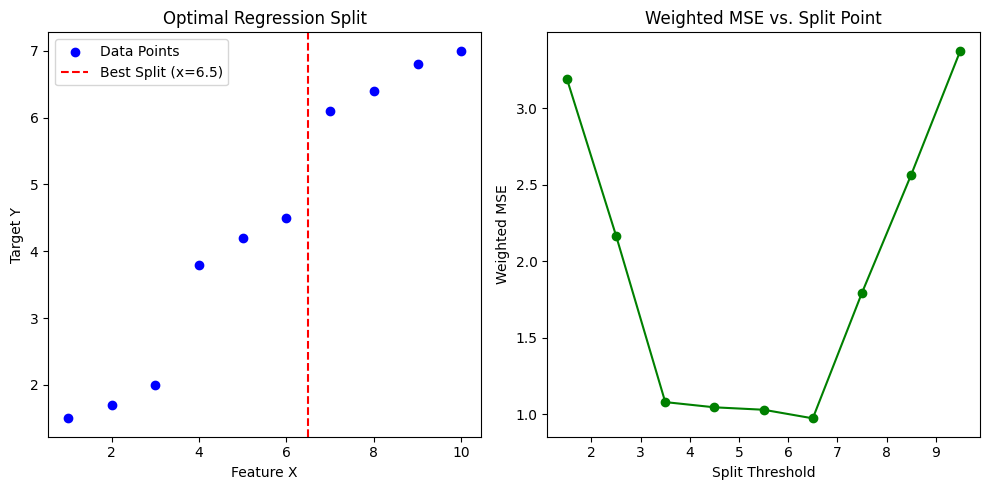

Optimal Split Threshold: 6.5
Minimum Weighted MSE achieved: 0.9742


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic data: Feature X and continuous target Y
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
Y = np.array([1.5, 1.7, 2.0, 3.8, 4.2, 4.5, 6.1, 6.4, 6.8, 7.0])

def calculate_mse(y):
    if len(y) == 0: return 0
    return np.mean((y - np.mean(y))**2)

# Possible splits (between each point)
split_points = (X[:-1] + X[1:]) / 2
mse_values = []

for s in split_points:
    left_y = Y[X <= s]
    right_y = Y[X > s]

    # Weighted MSE of the split
    weighted_mse = (len(left_y)/len(Y)) * calculate_mse(left_y) + (len(right_y)/len(Y)) * calculate_mse(right_y)
    mse_values.append(weighted_mse)

best_split = split_points[np.argmin(mse_values)]

# Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', label='Data Points')
plt.axvline(best_split, color='red', linestyle='--', label=f'Best Split (x={best_split})')
plt.title('Optimal Regression Split')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(split_points, mse_values, marker='o', color='green')
plt.title('Weighted MSE vs. Split Point')
plt.xlabel('Split Threshold')
plt.ylabel('Weighted MSE')
plt.tight_layout()
plt.show()

print(f'Optimal Split Threshold: {best_split}')
print(f'Minimum Weighted MSE achieved: {min(mse_values):.4f}')

## Pruning and Hyperparameters

### Subtask:
Explain the theory and intuition behind Decision Tree regularization through pruning and hyperparameter tuning.


### Combating Overfitting: Pruning and Hyperparameters

Decision Trees are notorious for **overfitting**. Because they can theoretically continue splitting until every leaf is pure, they often capture noise in the training data, leading to poor generalization on unseen data. Regularization is achieved through **Pruning**.

#### 1. Pre-pruning (Early Stopping)
Pre-pruning involves halting the construction of the tree before it reaches its maximum possible depth. This is controlled by several key hyperparameters:
*   **`max_depth`**: Limits the number of levels in the tree. A smaller depth prevents the tree from capturing fine-grained noise.
*   **`min_samples_split`**: The minimum number of samples a node must have before it can be split.
*   **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node. This smooths the model, especially in regression.
*   **`max_leaf_nodes`**: Limits the total number of leaves in the tree.

#### 2. Post-pruning (Cost Complexity Pruning)
Post-pruning allows the tree to grow to its full extent and then removes branches that provide little predictive power.

**Minimal Cost-Complexity Pruning** is a common technique where we seek to minimize a cost function:
$$R_\alpha(T) = R(T) + \alpha|T|$$
*   $R(T)$ is the total error (misclassification rate or MSE) of the tree $T$.
*   $|T|$ is the number of terminal nodes (leaves).
*   **`ccp_alpha` ($\alpha$)**: The complexity parameter. A greater $\alpha$ increases the penalty for having more leaves, resulting in smaller, simpler trees.

#### 3. The Bias-Variance Tradeoff
*   **Large Trees (Unpruned)**: Low Bias, High Variance (Overfitting).
*   **Small Trees (Pruned)**: High Bias, Low Variance (Underfitting).

Effective tuning involves finding the 'sweet spot' where the tree is complex enough to capture the signal but simple enough to ignore the noise.

## Python Implementation: Titanic Dataset

### Subtask:
Perform a complete Decision Tree analysis on the Titanic dataset, from data loading to feature importance visualization.


**Reasoning**:
I will start by loading the Titanic dataset and performing the necessary preprocessing steps to prepare it for the Decision Tree model.



In [8]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = sns.load_dataset('titanic')

# Basic Preprocessing
# Drop 'deck' due to many missing values, and 'embark_town', 'alive', 'who', 'adult_male', 'class' as they are redundant
df = df.drop(columns=['deck', 'embark_town', 'alive', 'who', 'adult_male', 'class'])

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categorical features
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex']) # male=1, female=0
df['embarked'] = le.fit_transform(df['embarked'])

print("Dataset preprocessed successfully.")
df.head()

Dataset preprocessed successfully.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


**Reasoning**:
I will split the data into training and testing sets, then train a DecisionTreeClassifier with a limited depth to prevent overfitting and evaluate its performance.



In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features and target
X_data = df.drop(columns=['survived'])
y_data = df['survived']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Classifier
# We set max_depth=3 for better interpretability and to avoid overfitting
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.7989

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



**Reasoning**:
I will visualize the trained Decision Tree to understand the decision logic and plot the feature importances to identify which variables were most influential in predicting survival.



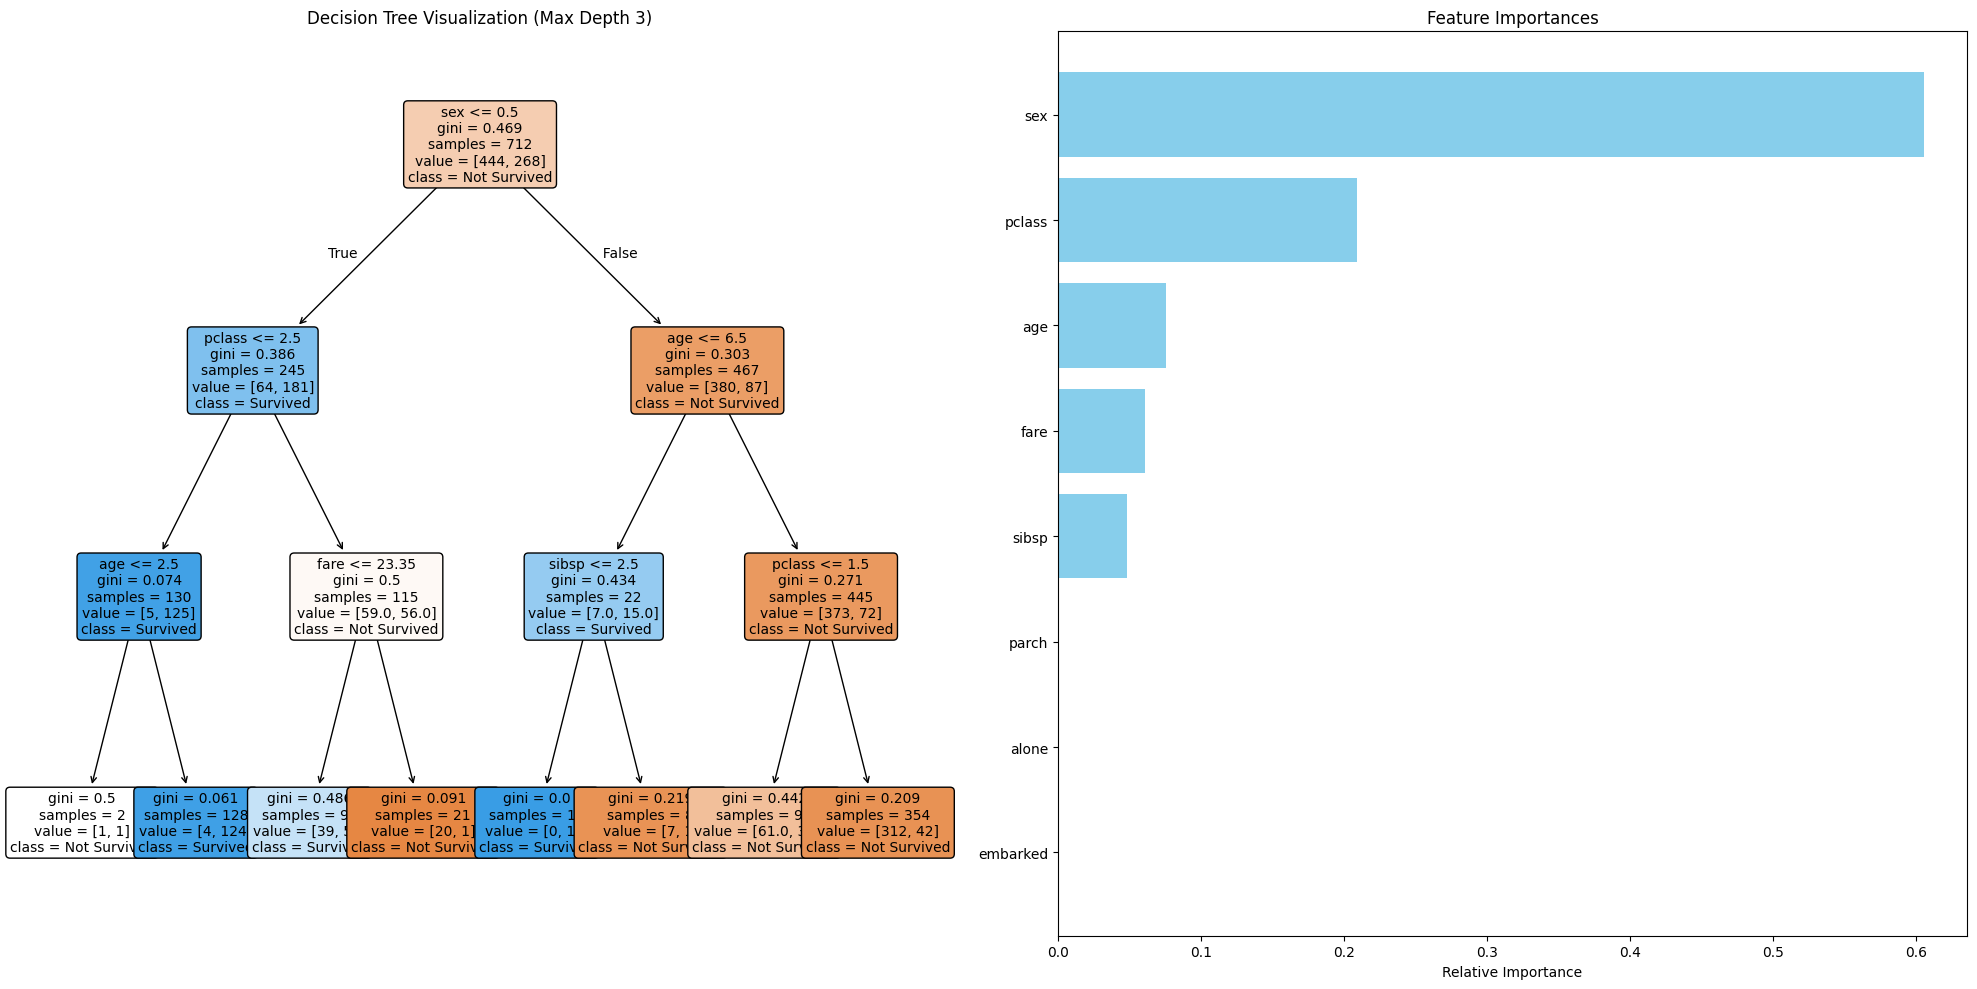

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np

# Set up the figure for two plots
plt.figure(figsize=(20, 10))

# 1. Visualize the Decision Tree
plt.subplot(1, 2, 1)
plot_tree(clf,
          feature_names=X_data.columns.tolist(),
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization (Max Depth 3)")

# 2. Plot Feature Importances
plt.subplot(1, 2, 2)
importances = clf.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X_data.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importances')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key takeaways for Decision Trees, including advantages, disadvantages, and practical tuning advice.


### Chapter 5 Summary: Decision Trees

Decision Trees are versatile machine learning models capable of performing both classification and regression tasks. Below is a final overview of their characteristics and practical application.

#### Pros and Cons

| **Advantages** | **Disadvantages** |
| :--- | :--- |
| **Interpretability**: Decision paths can be easily visualized and explained (White-box model). | **Instability**: Small variations in the data can result in a completely different tree structure. |
| **No Feature Scaling**: Requires little data preparation; no need for normalization or standardization. | **Overfitting**: Highly prone to creating overly complex trees that do not generalize well to new data. |
| **Handles Mixed Data**: Naturally handles both numerical and categorical features (specifically CART). | **Greedy Nature**: Algorithms make locally optimal choices at each node, which may not lead to a globally optimal tree. |
| **Non-linear**: Can capture non-linear relationships without needing complex transformations. | **Axis-Aligned Splits**: Since splits are perpendicular to axes, they struggle with diagonal patterns. |

#### Final Checklist for Choosing and Tuning

When working with Decision Trees in real-world scenarios, follow this checklist:

1.  **Check for Overfitting**: Always compare training accuracy vs. testing accuracy. If the training score is significantly higher, your tree is likely too deep.
2.  **Constraint the Depth**: Start with a small `max_depth` (e.g., 3-5) and increase it only if the model is underfitting.
3.  **Use `min_samples_leaf`**: To prevent the model from capturing noise, set a minimum number of samples for leaf nodes, especially for large datasets.
4.  **Consider `ccp_alpha`**: If the tree is still too complex, use Cost Complexity Pruning to find the optimal subtree.
5.  **Address Instability**: If the model is too sensitive to the training set, consider using an Ensemble method like **Random Forests** or **Gradient Boosting**, which average multiple trees to reduce variance.
6.  **Visualize**: Use `plot_tree` regularly during development to ensure the decision logic makes sense according to domain knowledge.